Heart Disease Prediction


Saving heart_disease_uci.csv to heart_disease_uci (3).csv
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3     

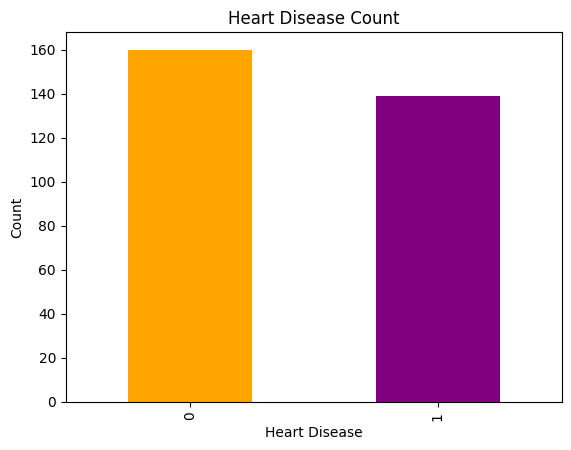

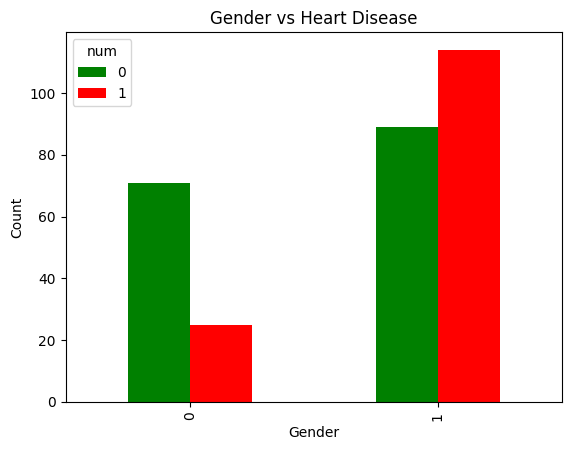

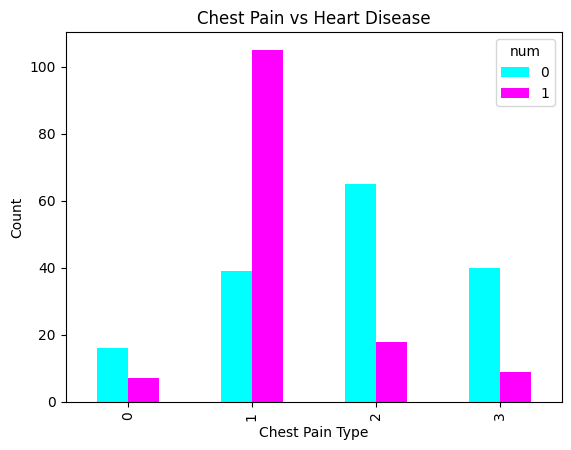

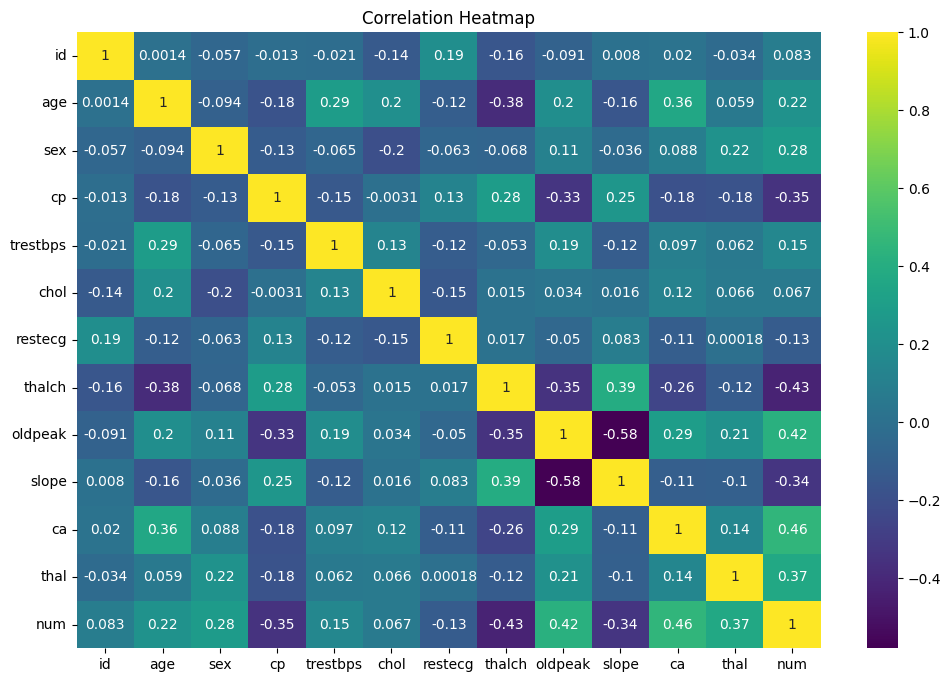

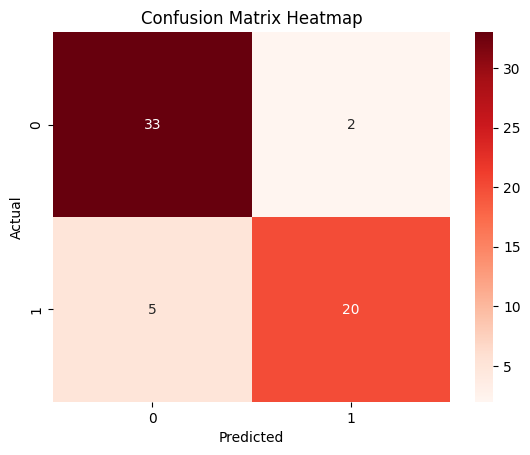

In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Upload Dataset
uploaded = files.upload()

# Load Dataset
data = pd.read_csv('heart_disease_uci.csv')

# Display First 5 Rows
print(data.head())

# Data Cleaning
data = data.dropna()

# Convert Target Column
data['num'] = data['num'].apply(
    lambda x: 1 if x > 0 else 0
)

# Encode Gender
data['sex'] = data['sex'].map({
    'Male': 1,
    'Female': 0
})

# Encode Categorical Columns
categorical_cols = [
    'cp',
    'restecg',
    'slope',
    'thal'
]

for col in categorical_cols:
    data[col] = pd.factorize(data[col])[0]

# Feature Selection
X = data[
    ['age',
     'sex',
     'cp',
     'trestbps',
     'chol',
     'fbs',
     'restecg',
     'thalch',
     'exang',
     'oldpeak',
     'slope',
     'ca',
     'thal']
]

y = data['num']

# Convert Features to Numeric
X = X.apply(pd.to_numeric)

# Fill Missing Values
X = X.fillna(X.median())

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Train Random Forest Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")

print(confusion_matrix(y_test, y_pred))

# Heart Disease Count Graph
data['num'].value_counts().plot(
    kind='bar',
    color=['orange', 'purple']
)

plt.title("Heart Disease Count")

plt.xlabel("Heart Disease")

plt.ylabel("Count")

plt.show()

# Gender vs Heart Disease Graph
gender_disease = pd.crosstab(
    data['sex'],
    data['num']
)

gender_disease.plot(
    kind='bar',
    color=['green', 'red']
)

plt.title("Gender vs Heart Disease")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

# Chest Pain vs Heart Disease Graph
cp_disease = pd.crosstab(
    data['cp'],
    data['num']
)

cp_disease.plot(
    kind='bar',
    color=['cyan', 'magenta']
)

plt.title("Chest Pain vs Heart Disease")

plt.xlabel("Chest Pain Type")

plt.ylabel("Count")

plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='viridis'
)

plt.title("Correlation Heatmap")

plt.show()

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix Heatmap")

plt.show()